In [6]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

# GENERAL RESULTS FOR EMRI CASE:

EMRI PARARMS: theta0: [1000000.0, 10.0, 0.9, 7.5, 0.5, 0.7853981633974483, 1.0, 0.9, 0.4]
SNR : **56.117062890601325**

## 1 PA best fit points : 
	
	final_overlap: 46.42853297850402
	x: [1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, 0.7773862440642697, 1.0071592783261298, 0.911151948599342, 0.5318777296989502]

read log files for recent two runs ig

## 0 PA best fit (BF) points 
	
	initial_overlap (at True Points): 
	Overlap of the best point: 46.42804326596721
	Best point : [1000378.9423449445, 10.002151720316922, 0.9002498890494179, 7.498421080025641, 0.49994972716957464, 0.775604643256901, 1.0070028955583723, 0.9224299313252369, 0.5279555698804296]

## Simple Deviation Term (from 0pa point)

	intial overlap will be same as 0pa best fit case
	final overlap: 46.42831467372913
	x_best_fit = [1000390.0113489988, 10.002306569996907, 0.9002559335131843, 7.498382634976983, 0.49994741597573256, 0.7756778259691656, 1.0079366497165376, 0.926069846560845, 0.5305166225569329, -0.6581922993213578, -0.0001271093015084592]

[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 6311629) PSD_funcs: (3, 3155814)
[TRUE] SNR: 44.679967
[TRUE] SNR - Channel 0: 31.680252
[TRUE] SNR - Channel 1: 31.413214
[TRUE] SNR - Channel 2: 2.423038
[INFO] Frequency resolution delta_f: 3.168754e-08 Hz, Number of frequency bins: 3155815
freq_max: 0.100000 Hz and Freq_min: 0.000000 Hz


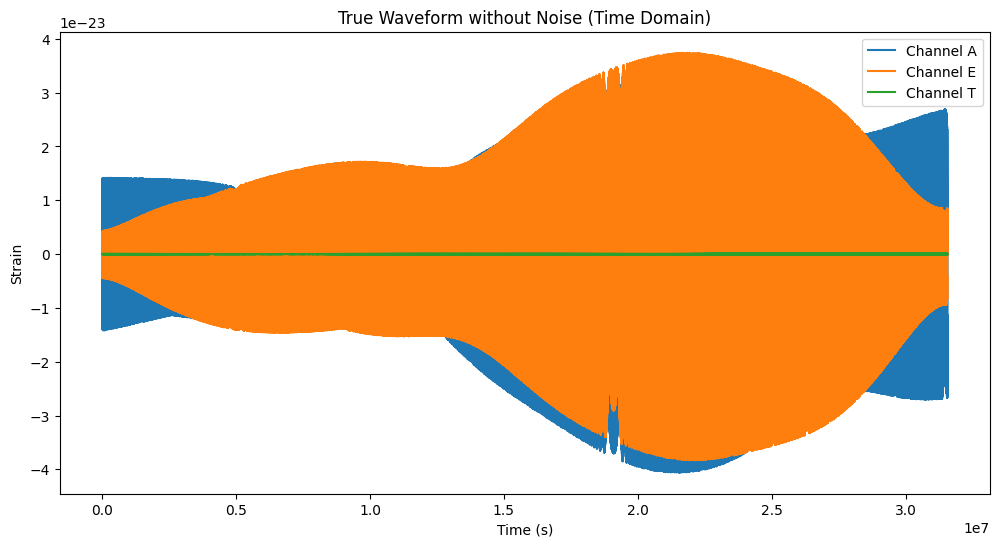

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 3155814)


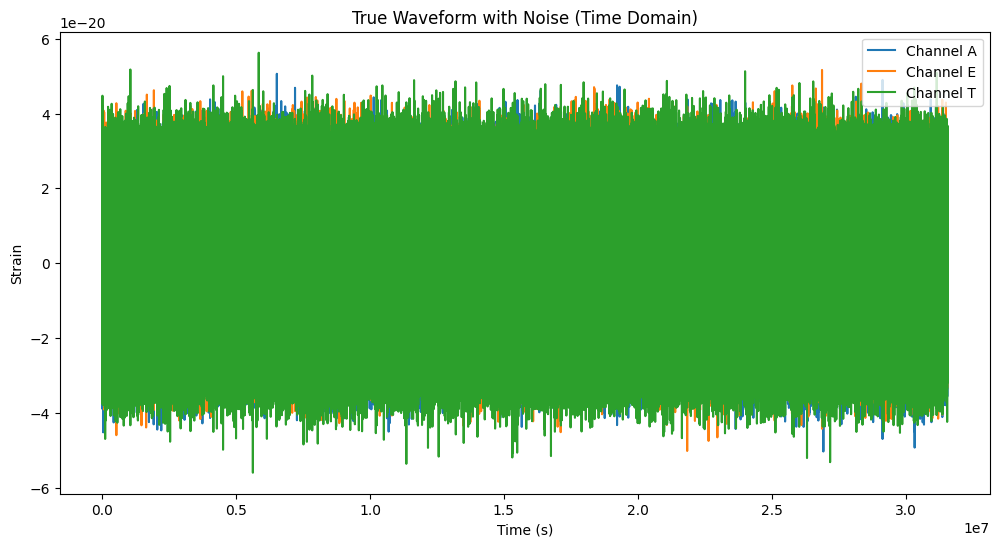

[ERROR] Noise model consistency check failed: Out of memory allocating 30,295,804,928 bytes (allocated so far: 70,384,118,272 bytes).
Noise consistency check results: None
[INFO] Finished preparing true waveform (GPU)


{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.9),
 'p0': np.float64(7.5),
 'e0': np.float64(0.5),
 'Y0': np.float64(1.0),
 'dist': np.float64(5.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 5,
 'T': 1.0,
 'chi2': 0.0,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1554dcaa7830>,
 'PSD_funcs': array([[6.81763650e-35, 1.70440916e-35, 7.57515208e-36, ...,
         4.26636463e-39, 4.26636171e-39, 4.26635879e-39],
        [6.81763650e-35, 1.70440916e-35, 7.57515208e-36, ...,
         4.26636463e-39, 4.26636171e-39, 4.26635879e-39],
        [2.65994852e-56, 1.06395802e-55, 2.39388950e-55, ...,
         1.65107196e-39, 1.65106498e-39, 1.65105800e-39]],
       shape=(3, 3155814)),
 'waveform_true_fft': array([[-6.25689989e-15+4.0676

In [7]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          5.0,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 5  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

# Overlap with Noise and With True Signal Without Noise

In [3]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']


In [4]:
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
])

## 1PA best fit

Best fit parameters for 1PA: [1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, 0.7773862440642697, 1.0071592783261298, 0.911151948599342, 0.5318777296989502]


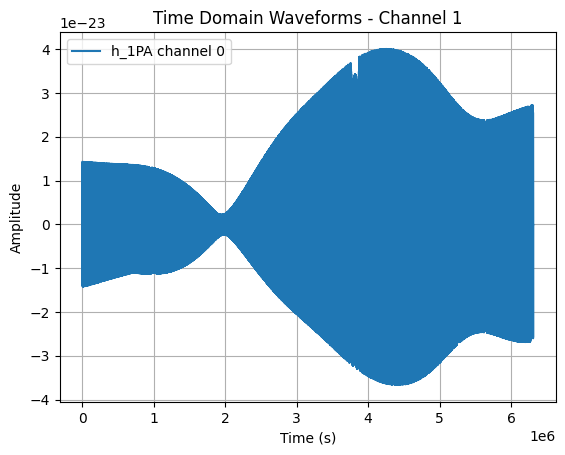

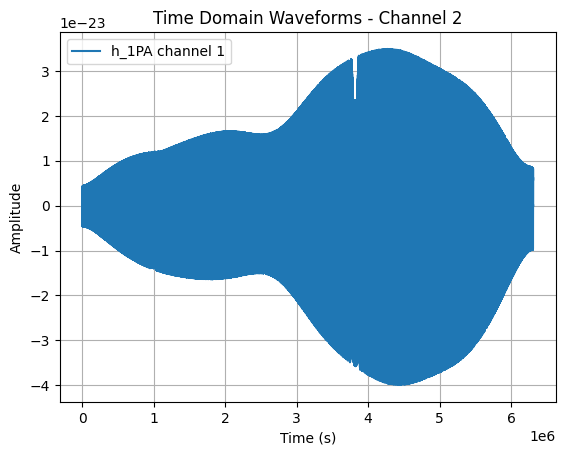

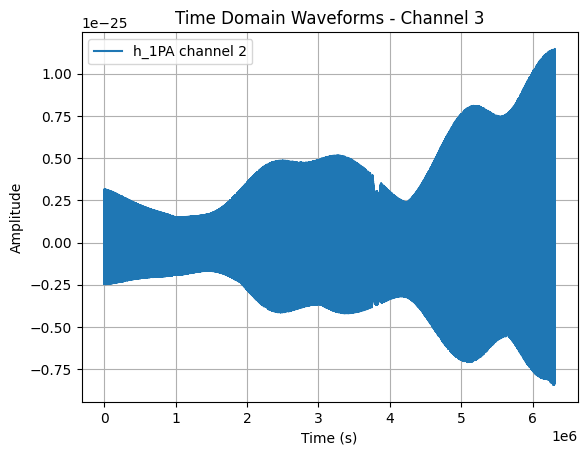

noise inner product with 1PA: 82.33151053088817
detection SNR for noise: 1.845288806750523
Actual overlap: 44.600189271999
detection SNR using true waveform: 44.5832441717535
detection SNR using actual signal: 46.42853297850402


In [ ]:
x_best_fit_1PA =  [1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, 0.7773862440642697, 1.0071592783261298, 0.911151948599342, 0.5318777296989502]
# x_best_fit_1PA =  true_params
print("Best fit parameters for 1PA:", x_best_fit_1PA)
add_kwargs = {'chi2': 0,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_1PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]
emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}
h_1PA = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_1PA[i].get(), label=f"h_1PA channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_1PA_f = compute_fft_with_windowing(h_1PA, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf = inner_prod(h_1PA_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 1PA:", n_hf)
optimal_snr_h_1PA = inner_prod(h_1PA_f, h_1PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR for noise:", n_hf/np.sqrt(optimal_snr_h_1PA))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_1PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_1PA))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_1PA)  + n_hf/np.sqrt(optimal_snr_h_1PA))

## 0PA best fit

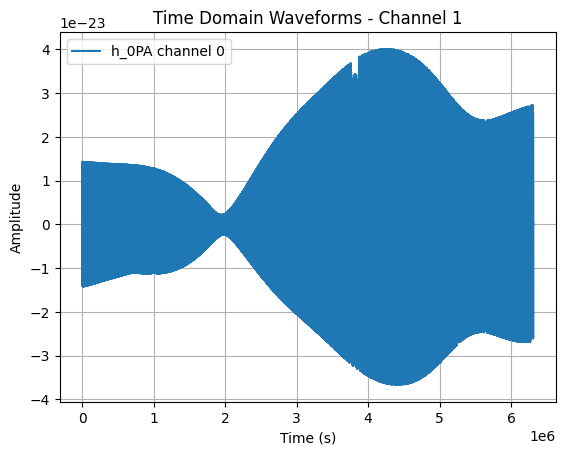

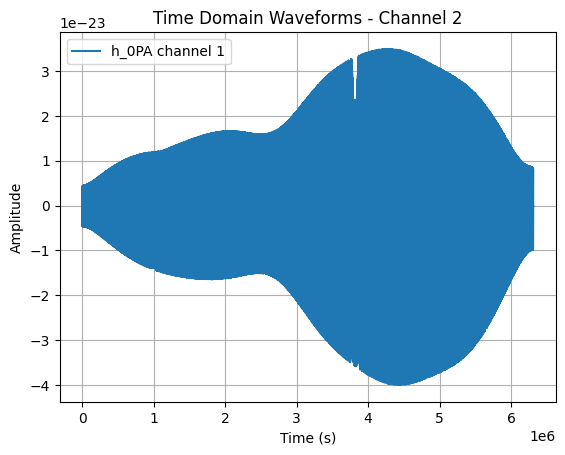

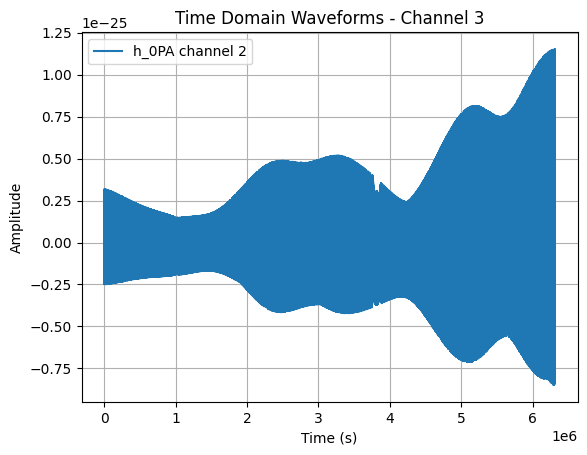

noise inner product with 0PA: 82.23632748762427
detection SNR 1.843895745413366
Actual overlap: 44.59168732060443
detection SNR using true waveform: 44.58414752055385
detection SNR using actual signal: 46.42804326596721


In [6]:
x_best_fit_0PA = [1000378.9423449445, 10.002151720316922, 0.9002498890494179, 7.498421080025641, 0.49994972716957464, 0.775604643256901, 1.0070028955583723, 0.9224299313252369, 0.5279555698804296]
add_kwargs = {'chi2': 0,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_0PA[i].get(), label=f"h_0PA channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_0PA_f = compute_fft_with_windowing(h_0PA, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf = inner_prod(h_0PA_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 0PA:", n_hf)
optimal_snr_h_0PA = inner_prod(h_0PA_f, h_0PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf/np.sqrt(optimal_snr_h_0PA))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_0PA)  + n_hf/np.sqrt(optimal_snr_h_0PA))

## 0PA best fit + deviation

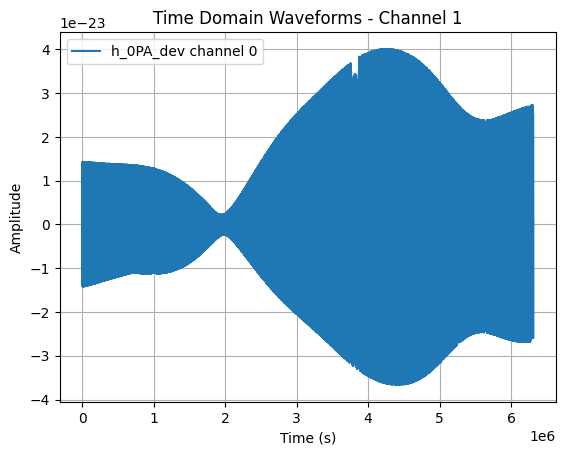

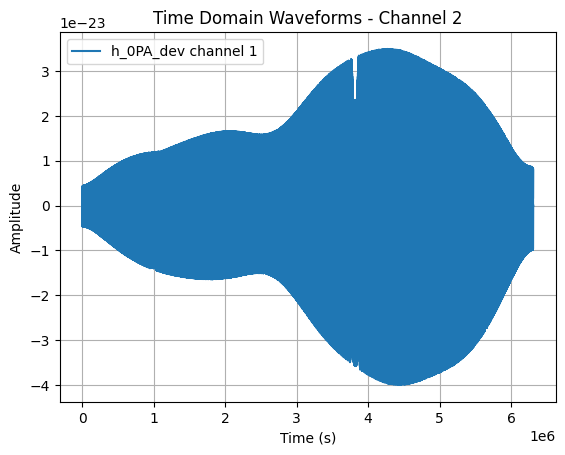

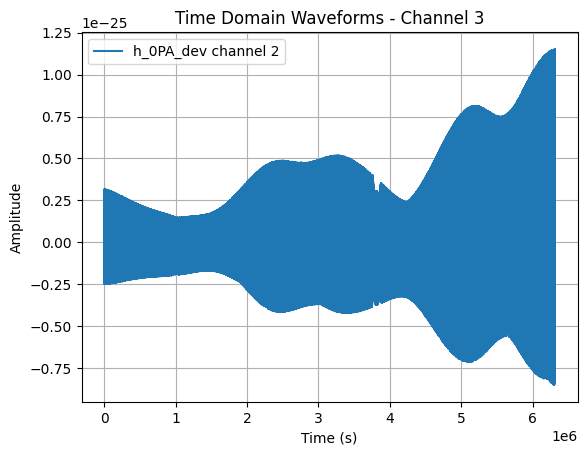

noise inner product with 0PA: 82.24938284846948
detection SNR 1.8439301797554135
Actual overlap: 44.59493243886961
detection SNR using true waveform: 44.584391657408595
detection SNR using actual signal: 46.428321837164006


In [7]:
x_best_fit_0PA_dev =  [1000390.0111866072, 10.002306562505291, 0.9002559335743326, 7.498382636395973, 0.4999474161077486, 0.775675249333267, 1.0079314746576018, 0.9262853817113597, 0.5305190107170585, -0.6582780852740936, -0.00012710912432646872]
add_kwargs = {'chi2': 0,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev

wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA_dev = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_0PA_dev[i].get(), label=f"h_0PA_dev channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_0PA_dev_f = compute_fft_with_windowing(h_0PA_dev, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf_dev = inner_prod(h_0PA_dev_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 0PA:", n_hf_dev)
optimal_snr_h_0PA_dev = inner_prod(h_0PA_dev_f, h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev)  + n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

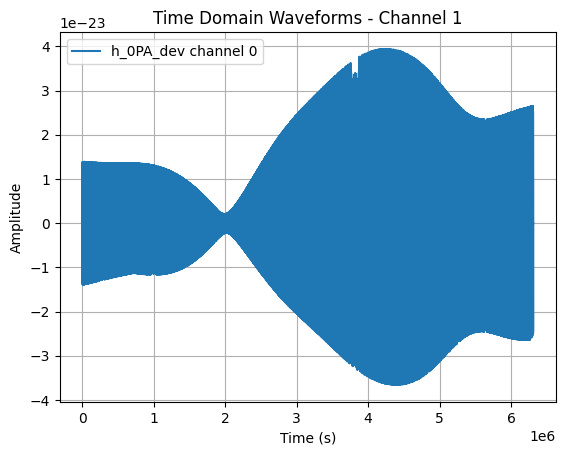

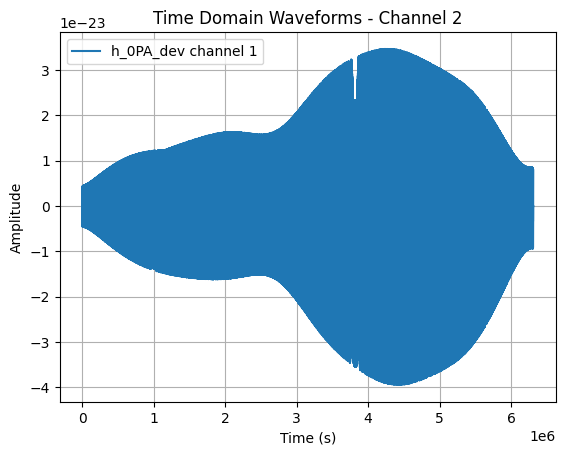

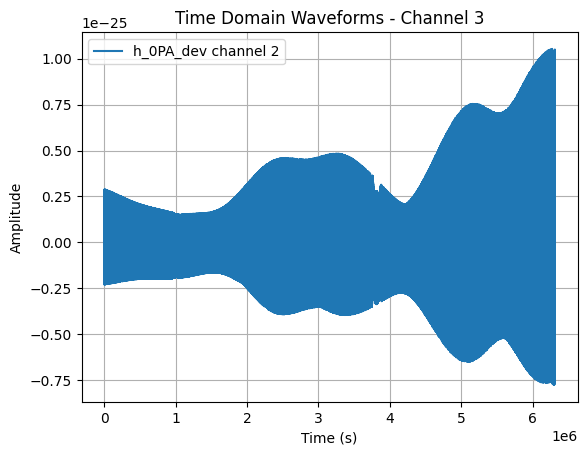

noise inner product with 0PA: 84.57931536558425
detection SNR 1.8784668451447515
Actual overlap: 44.79799572313912
detection SNR using true waveform: 44.57142679662222
detection SNR using actual signal: 46.44989364176697


In [8]:
x_best_fit_0PA_dev = [1002038.3813722954, 10.025943370684828, 0.9011207413909014, 7.492941226521536, 0.49956073300427833, 0.801622410950087, 1.0040861969244146, 0.9154664860678158, 0.49580785652582227, -92.0194392208667, -0.00016385951638481412]
add_kwargs = {'chi2': 0,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev

wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA_dev = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_0PA_dev[i].get(), label=f"h_0PA_dev channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_0PA_dev_f = compute_fft_with_windowing(h_0PA_dev, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf_dev = inner_prod(h_0PA_dev_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 0PA:", n_hf_dev)
optimal_snr_h_0PA_dev = inner_prod(h_0PA_dev_f, h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev)  + n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

## Marginals

/tmp/ipykernel_590560/4114493141.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


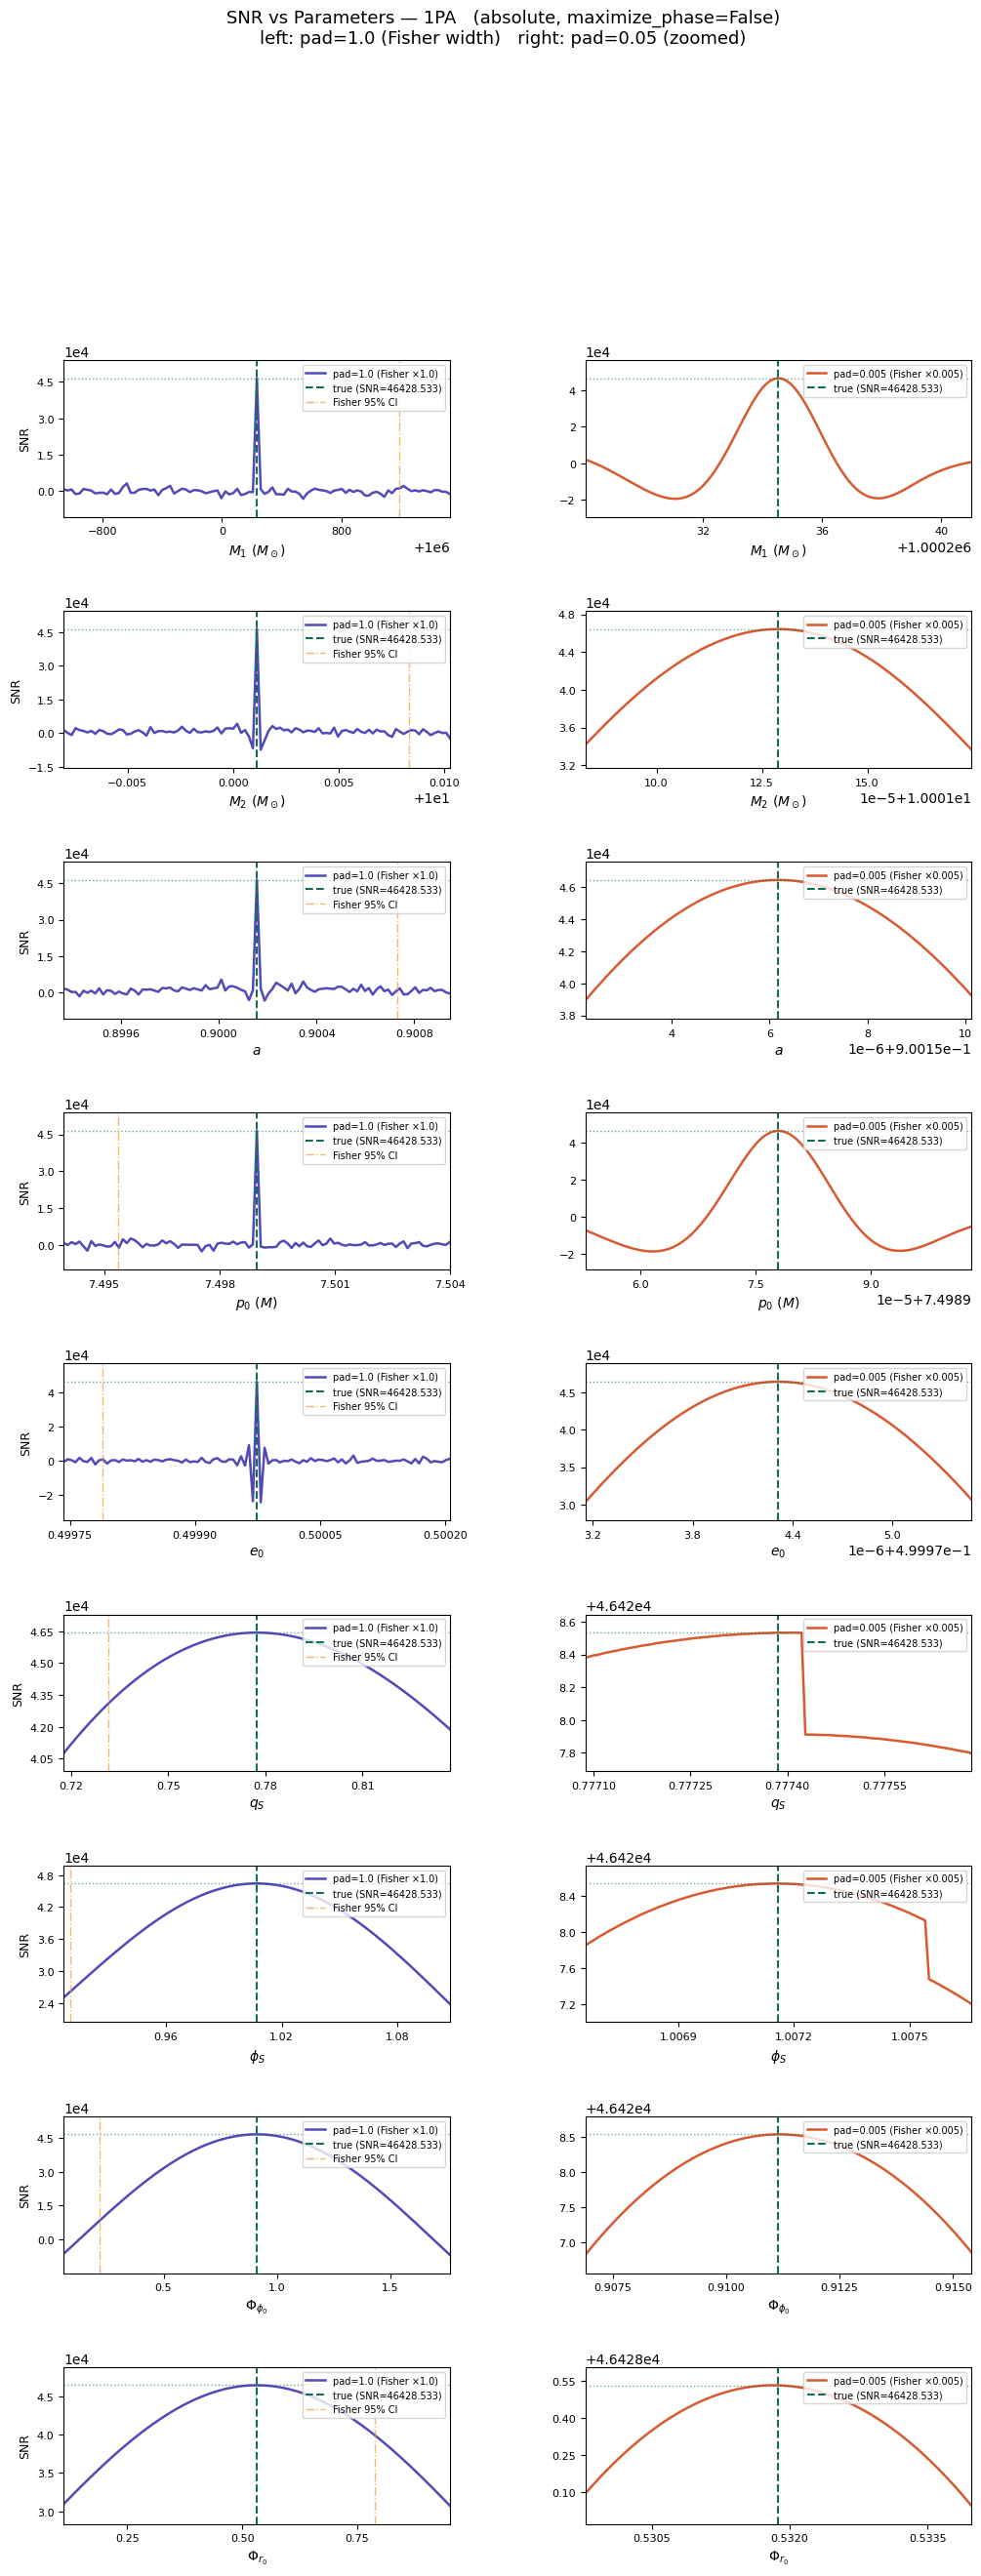

In [13]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']

x_best_fit_1PA =[1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, 0.7773862440642697, 1.0071592783261298, 0.911151948599342, 0.5318777296989502]

fisher_bounds = [(np.float64(998599.9273482531), np.float64(1001189.8010923311)),
                  (np.float64(9.990039089485286), np.float64(10.008369323493614)),
                (np.float64(0.8991505090825742), np.float64(0.9007301816792481)), 
                (np.float64(7.495361330683592), np.float64(7.505415323816738)), 
                (np.float64(0.4997895003791043), np.float64(0.5002533475356684)), 
                (np.float64(0.731403284186184), np.float64(0.8508927792517055)), 
                (np.float64(0.9101441037493914), np.float64(1.1105077832197476)), 
                (np.float64(0.21660657615456258), np.float64(1.9183081487576732)), 
                (np.float64(-0.05284618340259417), np.float64(0.7880393926035596))]


PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
]

add_kwargs = {'chi2': 0.0, 'evolve_1PA': True, 'evolve_primary': False, 'evolve_2PA': False,
              'deviation_included': True, 'dev_1': 0, 'dev_2': 0}

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_1PA)
N_POINTS    = 100
# pad is now a multiplier on the Fisher half-width centred on the true point.
# pad=1.0  → window = exactly the Fisher bounds
# pad=0.5  → window = half the Fisher width around true point (tighter zoom)
# pad=2.0  → window = twice the Fisher width (wider view)
PAD_FACTORS = [1.0, 0.005]


# ── Grid builder ───────────────────────────────────────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi    = fisher_bounds[idx]
    half      = (hi - lo) / 2.0        # half the Fisher width
    true_val  = x_best_fit_1PA[idx]

    # Window is pad * half_width on each side of the true point
    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    # Clip to physical bounds
    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    # Build two half-grids so true_val is always an exact node
    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,  true_val, n_left)
    right = np.linspace(true_val, raw_hi,  n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_1PA)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0 = theta
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_1PA[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)
    nrows = N_PARAMS

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            # Absolute SNR — no subtraction
            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            # True-point horizontal reference line
            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)

            # True-point vertical marker
            ax.axvline(x_best_fit_1PA[idx], color='#0F6E56',
                       lw=1.5, ls='--',
                       label=f'true (SNR={snr_true:.3f})')

            # Fisher bounds only on the wide (left) column —
            # in the zoomed right column they'd be off-screen anyway
            if col == 0:
                lo, hi = fisher_bounds[idx]
                ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
                ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.',  alpha=0.7,
                           label='Fisher 95% CI')

            # Stretch x-axis exactly to the computed grid (no padding gaps)
            ax.set_xlim(grid[0], grid[-1])

            # Y-limits: tight around the actual SNR range in this window
            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else snr_true * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 1PA   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.05 (zoomed)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()

    
if __name__ == '__main__':
    plot_snr_profiles()

/tmp/ipykernel_590560/1982518233.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


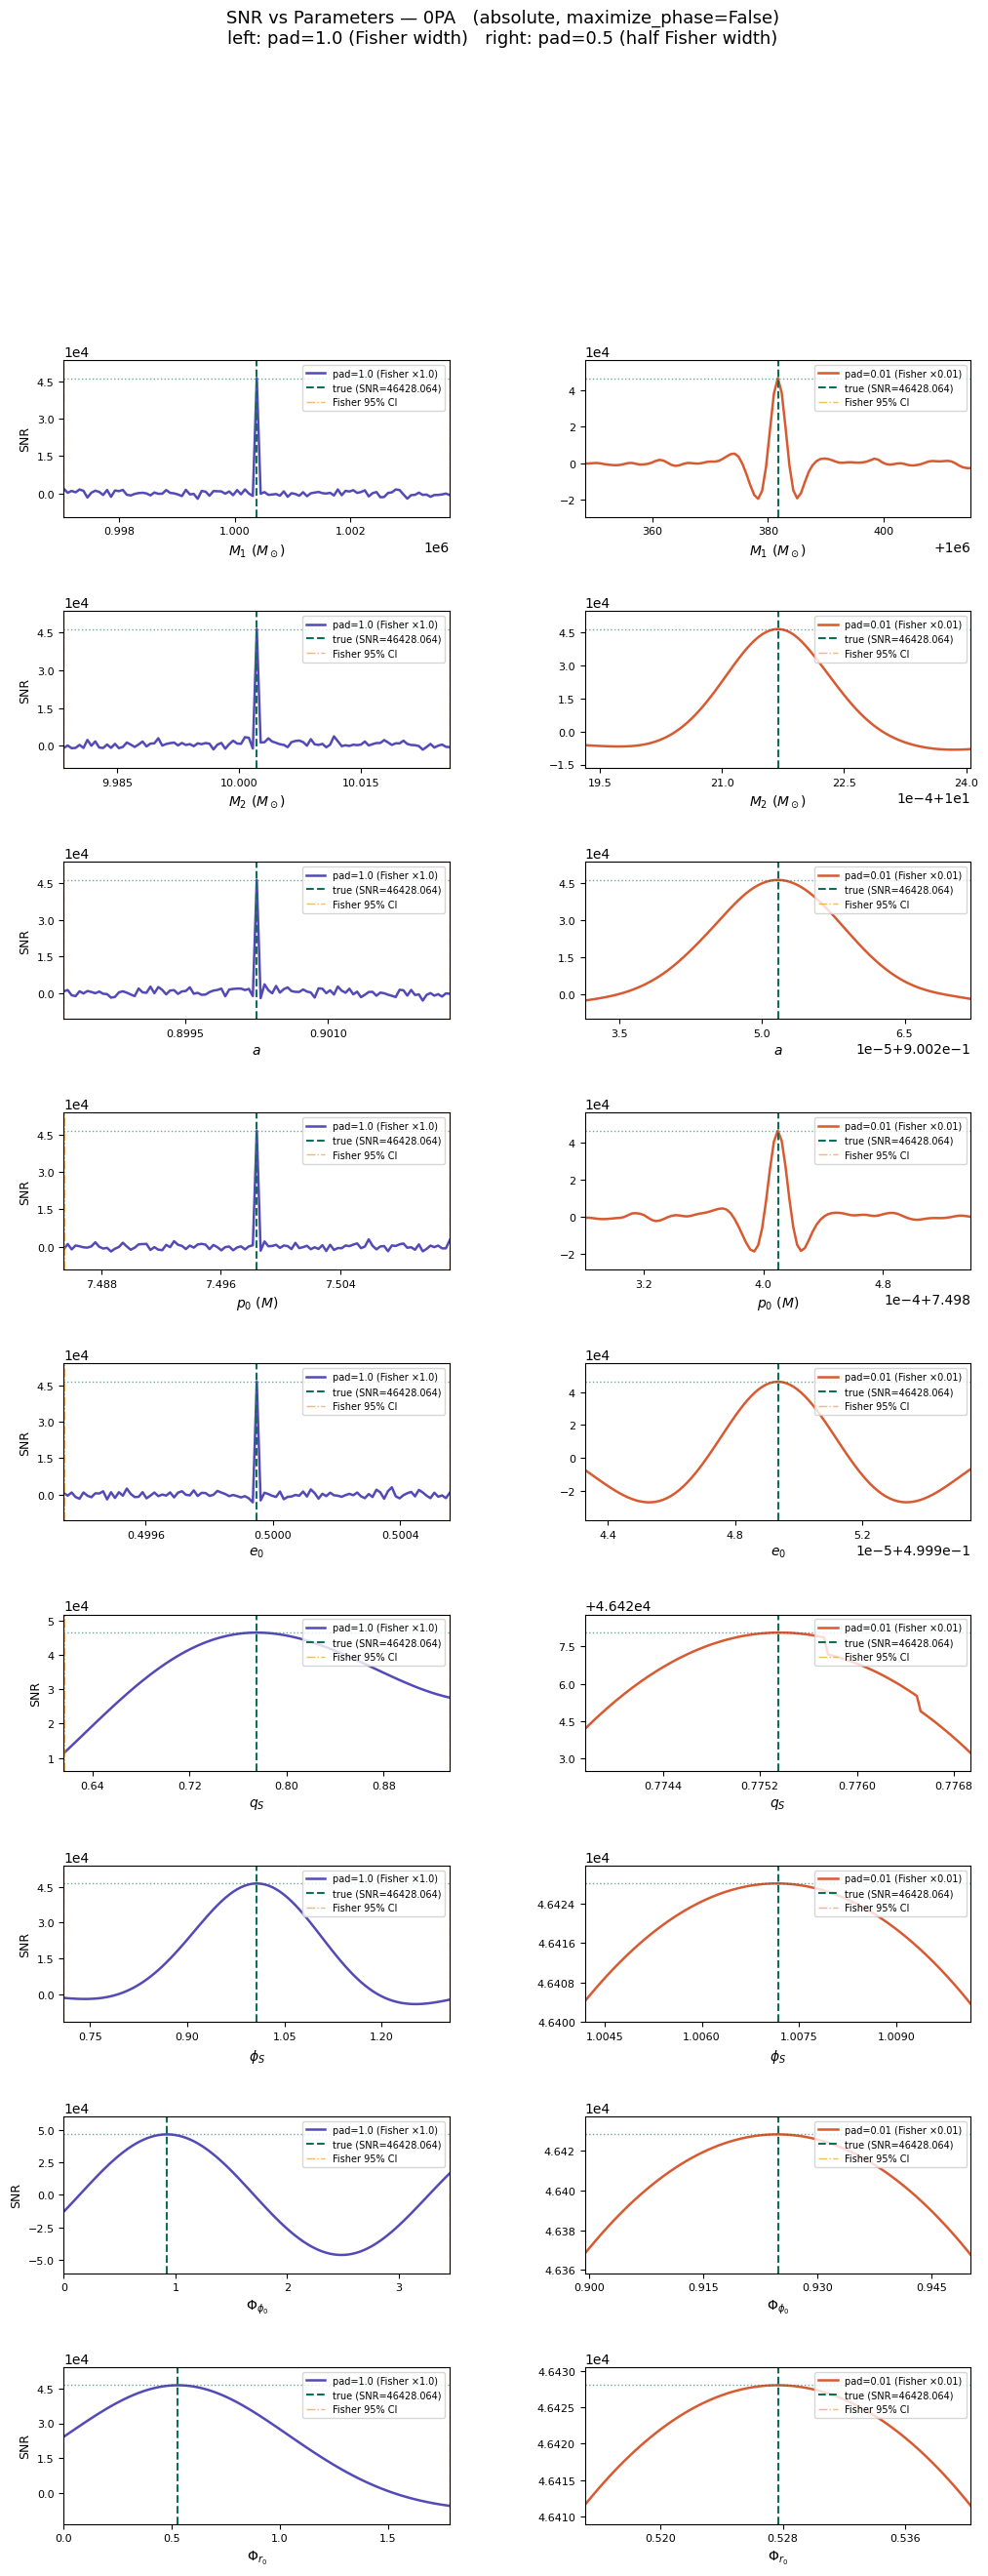

In [12]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']

x_best_fit_0PA = [1000381.7041232118, 10.002168695473182, 0.9002516907947907, 7.498409716347528, 0.49994934399028595, 0.7753479239641903, 1.0071736406662928, 0.9247980336593397, 0.527676177865538]
bounds_0PA = [(np.float64(997044.2000421624), np.float64(1003713.6846477265)),
               (np.float64(9.978460314343819), np.float64(10.025843126290026)), 
               (np.float64(0.8982239589328695), np.float64(0.9022758191659663)), 
               (np.float64(7.485493187372437), np.float64(7.511348972678845)), 
               (np.float64(0.49934330556074985), np.float64(0.5005561487783994)), 
               (np.float64(0.6164788222956328), np.float64(0.9347304632174547)), 
               (np.float64(0.7092445075255026), np.float64(1.304761215115033)), 
               (np.float64(-1.610102216481529), np.float64(3.4549329502800177)), 
               (np.float64(-0.7304167776458991), np.float64(1.7863279173014912))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
]

add_kwargs = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False, 'evolve_2PA': False,
              'deviation_included': True, 'dev_1': 0, 'dev_2': 0}

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_0PA)
N_POINTS    = 100
PAD_FACTORS = [1.0, 0.01]


# ── Grid builder — true point always an exact node ─────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = bounds_0PA[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA[idx]

    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA)          # FIX: was x_best_fit_1PA
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0 = theta
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)
    nrows = N_PARAMS

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            ax.set_xlim(grid[0], grid[-1])

            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)
            ax.axvline(x_best_fit_0PA[idx], color='#0F6E56',
                       lw=1.5, ls='--', label=f'true (SNR={snr_true:.3f})')

            lo, hi = bounds_0PA[idx]
            ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
            ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7,
                       label='Fisher 95% CI')

            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else snr_true * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 0PA   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.5 (half Fisher width)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

/tmp/ipykernel_1978194/659625290.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


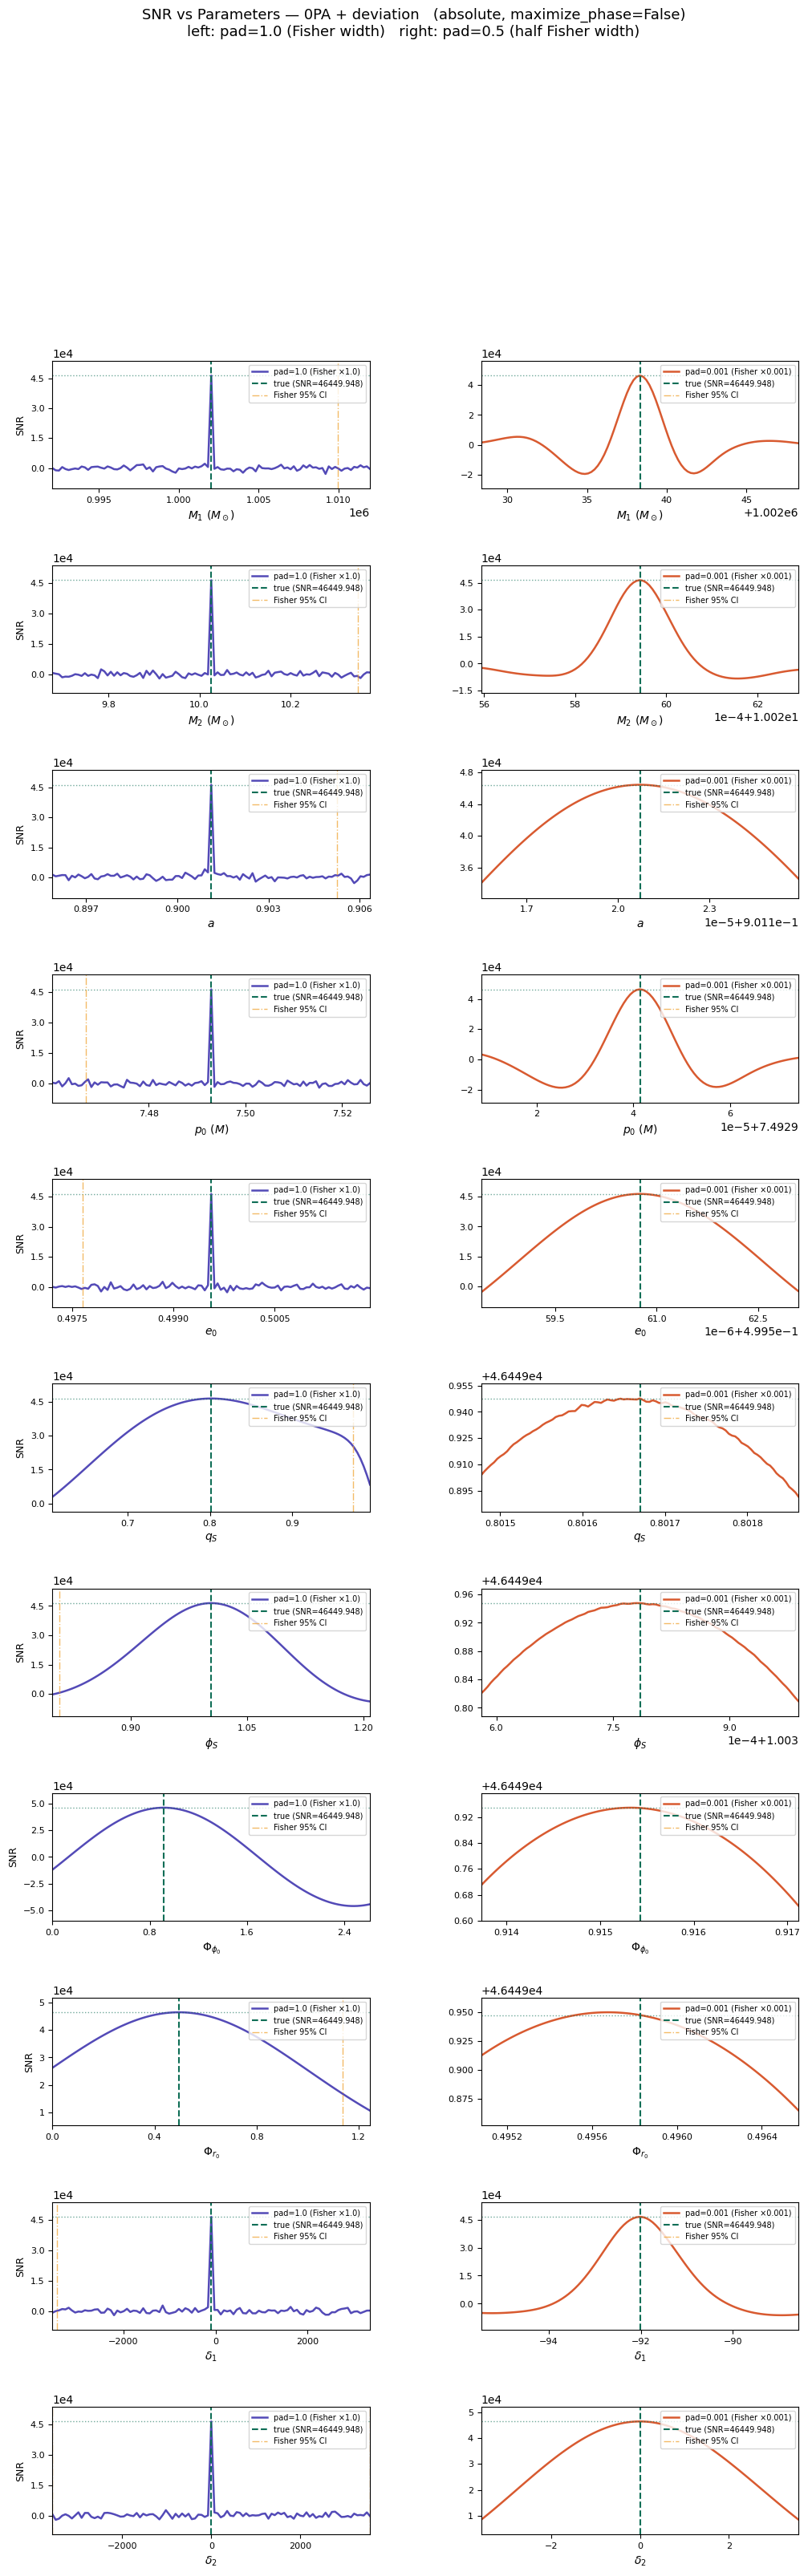

In [8]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
    r'$\delta_1$', r'$\delta_2$']

x_best_fit_0PA_dev = [1002038.3206946955, 10.025942269951084, 0.9011207263816821, 7.492941363053822, 0.499560753899444, 0.8016696937534229, 1.00378495940247, 0.9154248514732031, 0.4958258737144708, -92.01945190544691, -0.00016624654748756643]
bounds_0PA_dev =  [(np.float64(990056.2866793681), np.float64(1009961.3598157152)),
                  (np.float64(9.651225746662256), np.float64(10.347917357554838)),
                    (np.float64(0.8948030951316116), np.float64(0.9052446691147601)),
                      (np.float64(7.467039216264791), np.float64(7.532737549112275)),
                      (np.float64(0.4976592951836295), np.float64(0.5023586938214265)), 
                      (np.float64(0.5880971759164723), np.float64(0.9734358893379439)), 
                      (np.float64(0.808286354714354), np.float64(1.2172633556174672)), 
                      (np.float64(-0.6051971757225287), np.float64(2.789606202212151)), 
                      (np.float64(-0.36061355135458795), np.float64(1.1367307938051296)), 
                      (np.float64(-3446.923798543717), np.float64(3451.7391793083993)), 
                      (np.float64(-3573.486151948738), np.float64(3568.3443177581316))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (None, None),
    (None, None),
]

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_0PA_dev)
N_POINTS    = 100
# pad=1.0 → window = full Fisher width centred on true point
# pad=0.5 → window = half Fisher width (zoomed in)
PAD_FACTORS = [1.0, 0.001]


# ── Grid builder — true point always an exact node ─────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = bounds_0PA_dev[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA_dev[idx]

    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA_dev)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2 = theta
        # dev_1/dev_2 updated per iteration so varying them sweeps correctly
        add_kwargs = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': dev_1, 'dev_2': dev_2}
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA_dev[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)   # 2 columns: wide | zoomed
    nrows = N_PARAMS            # 11 rows, one per parameter

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            # horizontal reference at true-point SNR
            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)

            # vertical true-point marker
            ax.axvline(x_best_fit_0PA_dev[idx], color='#0F6E56',
                       lw=1.5, ls='--', label=f'true (SNR={snr_true:.3f})')

            # Fisher bounds as lines (visible at any zoom level)
            lo, hi = bounds_0PA_dev[idx]
            ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
            ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7,
                       label='Fisher 95% CI')

            # x-axis limits follow the grid exactly — different per pad and per panel
            ax.set_xlim(grid[0], grid[-1])

            # y-axis tight around SNR range in this window
            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else abs(snr_true) * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 0PA + deviation   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.5 (half Fisher width)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()